## Data Preprocessing


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Employee.csv")
df.head()

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0


In [ ]:
df.shape

(148, 6)

In [ ]:
df.columns

Index(['Company', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [ ]:
df.dtypes

,0
Company,object
Age,float64
Salary,float64
Place,object
Country,object
Gender,int64


1.Data Exploration

In [ ]:
df["Company"].unique()

array(['TCS', 'Infosys', 'CTS', nan, 'Tata Consultancy Services',
       'Congnizant', 'Infosys Pvt Lmt'], dtype=object)

In [ ]:
df["Age"].unique()

array([20., 30., 35., 40., 23., nan, 34., 45., 18., 22., 32., 37., 50.,
       21., 46., 36., 26., 41., 24., 25., 43., 19., 38., 51., 31., 44.,
       33., 17.,  0., 54.])

In [ ]:
df["Salary"].unique()

array([  nan, 2300., 3000., 4000., 5000., 6000., 7000., 8000., 9000.,
       1089., 1234., 3030., 3045., 3184., 4824., 5835., 7084., 8943.,
       8345., 9284., 9876., 2034., 7654., 2934., 4034., 5034., 8202.,
       9024., 4345., 6544., 6543., 3234., 4324., 5435., 5555., 8787.,
       3454., 5654., 5009., 5098., 3033.])

In [ ]:
df["Place"].unique()

array(['Chennai', 'Mumbai', 'Calcutta', 'Delhi', 'Podicherry', 'Cochin',
       nan, 'Noida', 'Hyderabad', 'Bhopal', 'Nagpur', 'Pune'],
      dtype=object)

In [ ]:
df["Country"].unique()

array(['India'], dtype=object)

In [ ]:
df["Gender"].unique()

array([0, 1])

In [ ]:
df.nunique()

,0
Company,6
Age,29
Salary,40
Place,11
Country,1
Gender,2


In [ ]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


2.Data Cleaning

In [ ]:
df.rename(columns={"Company": "Company_Name"}, inplace=True)

In [ ]:
df.columns

Index(['Company_Name', 'Age', 'Salary', 'Place', 'Country', 'Gender'], dtype='object')

In [ ]:
df.isnull().sum()

,0
Company_Name,8
Age,18
Salary,24
Place,14
Country,0
Gender,0


In [ ]:
(df["Age"] == 0).sum()

np.int64(6)

In [ ]:
df["Age"] = df["Age"].replace(0, np.nan)

In [ ]:
df["Age"].isnull().sum()

np.int64(24)

In [ ]:
df['Company_Name'] = df['Company_Name'].replace({
    'Tata Consultancy Services': 'TCS',
    'Infosys Pvt Lmt': 'Infosys',
    'Congnizant': 'Cognizant'
})

In [ ]:
df['Place'] = df['Place'].replace({
    'Podicherry': 'Pondicherry'
})

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Salary"] = df["Salary"].fillna(df["Salary"].median())

In [ ]:
df["Company_Name"] = df["Company_Name"].fillna(df["Company_Name"].mode()[0])
df["Place"] = df["Place"].fillna(df["Place"].mode()[0])
df['Country'] = df['Country'].fillna(df['Country'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Company_Name,0
Age,0
Salary,0
Place,0
Country,0
Gender,0


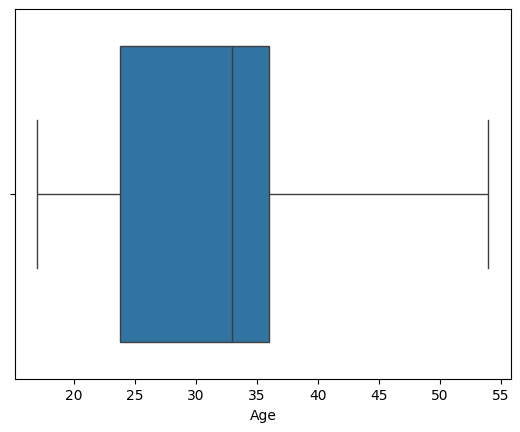

In [ ]:
sns.boxplot(x=df["Age"])
plt.show()

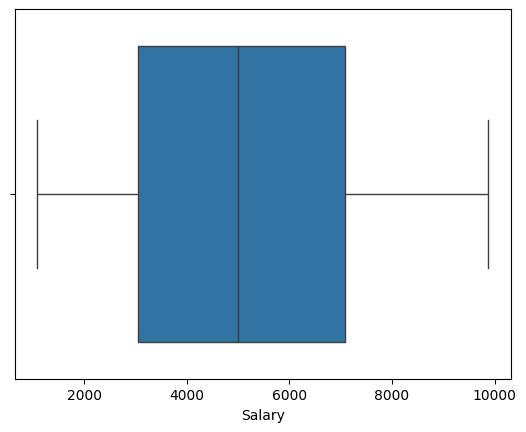

In [ ]:
sns.boxplot(x=df["Salary"])
plt.show()

In [ ]:
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

outliers_age = df[(df['Age'] < lower) | (df['Age'] > upper)]

print("Age outliers:")
print(outliers_age)

Lower limit: 5.375
Upper limit: 54.375
Age outliers:
Empty DataFrame
Columns: [Company_Name, Age, Salary, Place, Country, Gender]
Index: []


In [ ]:
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower limit:", lower)
print("Upper limit:", upper)

outliers_salary = df[
    (df['Salary'] < lower) |
    (df['Salary'] > upper)
]

print("Salary outliers:")
print(outliers_salary)

Lower limit: -3013.5
Upper limit: 13142.5
Salary outliers:
Empty DataFrame
Columns: [Company_Name, Age, Salary, Place, Country, Gender]
Index: []


3.Data Analysis

In [ ]:
data = df[(df["Age"] > 40) & (df["Salary"] < 5000)]
data

,Company_Name,Age,Salary,Place,Country,Gender
21,Infosys,50.0,3184.0,Delhi,India,0
32,Infosys,45.0,4034.0,Calcutta,India,0
39,Infosys,41.0,3000.0,Mumbai,India,0
50,Infosys,41.0,3000.0,Chennai,India,0
57,Infosys,51.0,3184.0,Hyderabad,India,0
68,Infosys,43.0,4034.0,Mumbai,India,0
75,Infosys,44.0,3000.0,Cochin,India,0
86,Infosys,41.0,3000.0,Delhi,India,0
93,Infosys,54.0,3184.0,Mumbai,India,0
104,Infosys,44.0,4034.0,Delhi,India,0


In [ ]:
print("Number of employees:", len(data))

Number of employees: 15


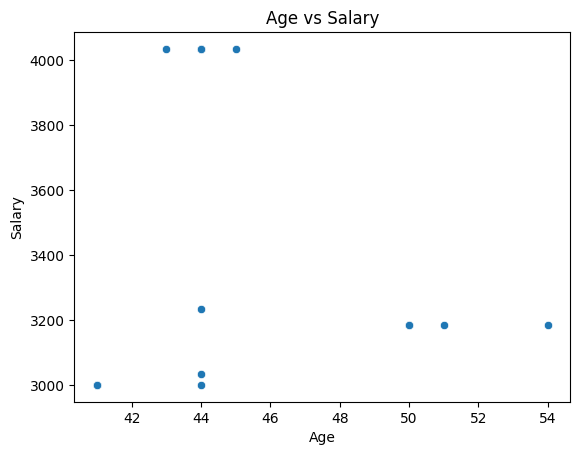

In [ ]:
sns.scatterplot(x="Age", y="Salary", data=data)

plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary")

plt.show()

In [ ]:
place_count = df['Place'].value_counts()
print(place_count)

Place
Mumbai         48
Calcutta       32
Chennai        14
Delhi          14
Cochin         13
Noida           8
Hyderabad       8
Pondicherry     3
Pune            2
Bhopal          1
Nagpur          1
Name: count, dtype: int64


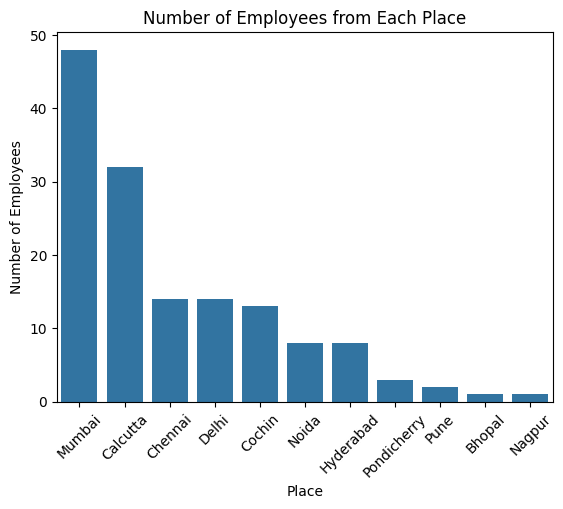

In [ ]:
sns.barplot(x=place_count.index, y=place_count.values)

plt.xlabel("Place")
plt.ylabel("Number of Employees")
plt.title("Number of Employees from Each Place")
plt.xticks(rotation=45)
plt.show()

4.Data Encoding

In [ ]:
df = pd.get_dummies(df, columns=["Company_Name", "Place", "Country"])
df.head()

,Age,Salary,Gender,Company_Name_CTS,Company_Name_Cognizant,Company_Name_Infosys,Company_Name_TCS,Place_Bhopal,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune,Country_India
0,20.0,5000.0,0,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,True
1,30.0,5000.0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True
2,35.0,2300.0,0,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True
3,40.0,3000.0,0,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True
4,23.0,4000.0,0,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True


In [ ]:
df.columns

Index(['Age', 'Salary', 'Gender', 'Company_Name_CTS', 'Company_Name_Cognizant',
       'Company_Name_Infosys', 'Company_Name_TCS', 'Place_Bhopal',
       'Place_Calcutta', 'Place_Chennai', 'Place_Cochin', 'Place_Delhi',
       'Place_Hyderabad', 'Place_Mumbai', 'Place_Nagpur', 'Place_Noida',
       'Place_Pondicherry', 'Place_Pune', 'Country_India'],
      dtype='object')

5.Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
standard_data = scaler.fit_transform(df)

In [ ]:
standard_df = pd.DataFrame(standard_data, columns=df.columns)

In [ ]:
standard_df.head()

,Age,Salary,Gender,Company_Name_CTS,Company_Name_Cognizant,Company_Name_Infosys,Company_Name_TCS,Place_Bhopal,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune,Country_India
0,-1.484676,-0.100827,-0.534522,-0.566658,-0.118678,-0.67420,1.150035,-0.083624,-0.534522,3.047247,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678,0.0
1,-0.267174,-0.100827,-0.534522,-0.566658,-0.118678,1.48324,-0.869539,-0.083624,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678,0.0
2,0.341577,-1.243735,-0.534522,-0.566658,-0.118678,-0.67420,1.150035,-0.083624,1.870829,-0.328165,-0.315018,-0.328165,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678,0.0
3,0.950328,-0.947426,-0.534522,-0.566658,-0.118678,1.48324,-0.869539,-0.083624,-0.534522,-0.328165,-0.315018,3.047247,-0.242536,-0.707107,-0.083624,-0.242536,-0.145865,-0.118678,0.0
4,-1.119426,-0.524127,-0.534522,-0.566658,-0.118678,-0.67420,1.150035,-0.083624,-0.534522,-0.328165,-0.315018,-0.328165,-0.242536,1.414214,-0.083624,-0.242536,-0.145865,-0.118678,0.0


In [ ]:
scaler = MinMaxScaler()

minmax_data = scaler.fit_transform(df)

minmax_df = pd.DataFrame(minmax_data, columns=df.columns)

minmax_df.head()

,Age,Salary,Gender,Company_Name_CTS,Company_Name_Cognizant,Company_Name_Infosys,Company_Name_TCS,Place_Bhopal,Place_Calcutta,Place_Chennai,Place_Cochin,Place_Delhi,Place_Hyderabad,Place_Mumbai,Place_Nagpur,Place_Noida,Place_Pondicherry,Place_Pune,Country_India
0,0.081081,0.445089,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.351351,0.445089,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.486486,0.137817,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.621622,0.217480,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.162162,0.331285,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
